# Part d

The goal of this part of the exercise entailed using an LLM to geneate additional labeled training examples to address
scarcity since we were only using 32 labeled examples, then measure whether this additional data emproves the BERT classifier decided form part a.


#### Data generation 

How we generated the labeled examples:

- We used OPENAI api (GPT-4O-MINI) to generate synthetic reviews.
- The data was generated conditional on both dimensions of the data: each start rating (1-5) and each category (Travel & Vacation and Media $ Publishing), so 
genereation was done per category and per cell rather than per star alone.
- Each prompt describes the target rating tone in a contrastive way, meaning what a 1 star ratings feels like vs a 5 star rating feels like putting emphasis on the harder middle ratings (2/3/4), so the  model produces reviews that actually match their assigned star instead of collapsing them towards the extremes.
- We generate 290 per star reviews, split across the two categories giving a total of 1450 synthetic reviews.


Prompts were seeded with real examples in two different ways:

- real labeled reviews for the exact star & category pair were shown to the LLM to macth the rating tone
- real unlabeled reviews of a certain category were shown to the model so it copies the authentic subject matter and vocabulary but explicitly prompt the LLM to copy topic not sentiment.

*Only the 25 training rows and unlabeled reviews were used as seeds to avoid lekeage, the validation reviews were never showened to the LLM*

Moreover, we used a **judge model**. LLM's dont reliably produce text matching the requested label meaning  a "3 star" prompt sometimes may yield a clearly positive of negative text. Training on these mislabeled exampels would teach the classifier model wrong associations. In order to catch this, we introudce a "judge model", we train a **bert-base-uncased** on the 25 real examples, we then pass every synthetic review through it, the judge predicts a star and we compare it to the star the star the review was generated as. If the judge's prediciont was 2 or more stars away from the generated label, the review is dropped. One obvious honest limitation is that the judge model itself is weak, we only trained it on 25 examples so it removes gross mismatched rather than serving as ground truth. So, it catches a furious review mislabeled as a 5 star but it makes plentyof birderline mistakes.

After the judge model removes no singal reviews, we keep approx. 900 out of the 1500 reviews



#### Training and evaluation

We train the same BERT as part a, so the only variable change is the data. For evaluation we use 5 fold stratified CV over the 32 real labeled examples, rather than a single fixed validaiton split. As previously explain, the choice is deliberate: with only 32 examples , a single 7 review validation set makes every metric depend heavily on which reviews happen to land in tht split, making the numbers highly unstable. Cross validation, as it rotates the held out fold so that every example is tested exactly once and we pool the prediciotns across folds before computing metrics, gives us a more reliable estimate.

One important observation fo the setup is that only the real data is rotataed through the cross validaiton folds, and the model is only ever evaluated on the real reviews. The synthetic data is never placed in the test fold, it is added exclusively to the training portion of each fold. This makes the evaluation measure the real world predicitve performance and prevents any leakage, since the model is never being scored on generated text.

We compare two configuratiosn of the model:

- 5 fold CV on the real 32 labeled examples only, no synthetic data.
- real plus synthetic data: the same folds, but with all the synthetic reviews added to the training  set of each fold.

One observation is we dont include a "synthetic only" configuration  since under cross validation the folds are constructed fro the real data and each fold always contributes its real training portio and so a configuration that only trains with synthetic data alone does not fit the cross validation design we are using.


**Code was based on class 5 & 6 and written with Claude code**

## set up

In [2]:
import os, sys, re, json, asyncio
import numpy as np
import pandas as pd
from dotenv import load_dotenv

try:
    import nest_asyncio
    nest_asyncio.apply()
except Exception:
    pass

# find project root (folder containing data/ and scripts/), portable for teammates
root = os.getcwd()
while not (os.path.isdir(os.path.join(root, "data")) and os.path.isdir(os.path.join(root, "scripts"))):
    parent = os.path.dirname(root)
    if parent == root:
        raise RuntimeError("Could not locate project root")
    root = parent
os.chdir(root)                       # anchor cwd to a real dir (avoids deleted-cwd errors)
sys.path.append(os.path.join(root, "scripts"))

from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from datasets import Dataset as HFDataset

from utils import Metrics, preprocess_for_bert
# reuse part a's BERT + the shared k-fold CV (single source of truth)
from Part_2_BERT import (
    train_bert, evaluate_with_kfold, metrics_val,
    tokenizer, to_hf_dataset, tokenize, checkpoint, max_length,
)

load_dotenv(os.path.join(root, "scripts", ".env"))

REAL_CSV = os.path.join(root, "data", "filtered_reviews.csv")
TEXT_COL, LABEL_COL, CAT_COL = "review", "stars", "category"
num_labels = 5
GEN_MODEL = "gpt-4o-mini"
PER_STAR = 290
BATCH_SIZE_GEN = 10
MAX_CONCURRENT = 20
N_LABEL_SEEDS = N_STYLE_SEEDS = 3
seed = 123
np.random.seed(seed)


## Generation helpers & prompt

In [35]:
from openai import AsyncOpenAI
async_client = AsyncOpenAI()

def star_to_label(s): return int(s) - 1
def label_to_star(l): return int(l) + 1

STAR_GUIDANCE = {
    1: "a furious, deeply dissatisfied customer. Major problems, you feel cheated, no redeeming qualities. Strong negative language.",
    2: "a dissatisfied customer. Poor experience with significant problems, but one or two minor things were tolerable. Mostly negative, not as scathing as the very worst reviews.",
    3: "a neutral, mixed customer. Genuinely torn: some things fine, others disappointing. Balanced, lukewarm, neither recommending nor warning off. The most ambivalent tone.",
    4: "a satisfied customer with a minor caveat. Mostly positive, you'd recommend it, but note one small flaw. More positive than mixed, not gushing.",
    5: "a delighted customer. Everything exceeded expectations. Warm, glowing praise, would strongly recommend. No complaints.",
}

def build_prompt(star, category, n, label_seeds, style_seeds):
    label_block = ""
    if label_seeds:
        joined = "\n".join(f'  - "{s}"' for s in label_seeds)
        label_block = f"\nReal examples of {star}-star '{category}' reviews (match this rating's tone):\n{joined}\n"
    style_block = ""
    if style_seeds:
        joined = "\n".join(f'  - "{s}"' for s in style_seeds)
        style_block = f"\nExamples of the topics/vocabulary real '{category}' reviews use (any rating — copy the SUBJECT MATTER, not the sentiment):\n{joined}\n"
    return f"""You are generating realistic Trustpilot-style customer reviews in the category "{category}".

Write {n} DISTINCT reviews from the point of view of {STAR_GUIDANCE[star]}
{label_block}{style_block}
Requirements:
- Each review reflects EXACTLY a {star}-out-of-5 star rating in tone and content.
- Stay on-topic for the "{category}" category.
- Vary length (1-5 sentences), wording, and what is praised or criticised. Avoid repeating openings.
- Sound like a real customer, not a critic. Do NOT mention the star number in the text.
- Output ONLY valid JSON: a list of objects, each {{"review": "<text>"}}. No markdown, no commentary."""

async def generate_for_cell(star, category, total, seeds, semaphore):
    label_seeds = seeds["label"].get((star, category), [])
    style_seeds = seeds["style"].get(category, [])
    out = []
    async def one_batch(n):
        async with semaphore:
            ls = list(np.random.choice(label_seeds, min(N_LABEL_SEEDS, len(label_seeds)), replace=False)) if label_seeds else []
            ss = list(np.random.choice(style_seeds, min(N_STYLE_SEEDS, len(style_seeds)), replace=False)) if style_seeds else []
            try:
                resp = await async_client.chat.completions.create(
                    model=GEN_MODEL,
                    messages=[{"role": "user", "content": build_prompt(star, category, n, ls, ss)}],
                    temperature=0.9, max_tokens=1500)
                content = re.sub(r"^```(json)?|```$", "", resp.choices[0].message.content.strip()).strip()
                items = json.loads(content)
                return [{"review": it["review"].strip(), "stars": star, "category": category}
                        for it in items if isinstance(it, dict) and it.get("review", "").strip()]
            except Exception as e:
                print(f"  [star {star} | {category}] batch error: {e}")
                await asyncio.sleep(2)
                return []
    n_batches = total // BATCH_SIZE_GEN + (1 if total % BATCH_SIZE_GEN else 0)
    tasks = [one_batch(min(BATCH_SIZE_GEN, total - i * BATCH_SIZE_GEN)) for i in range(n_batches)]
    for batch in await asyncio.gather(*tasks):
        out.extend(batch)
    return out[:total]

async def generate_all(categories, seeds):
    sem = asyncio.Semaphore(MAX_CONCURRENT)
    per_cat = PER_STAR // len(categories)
    rows = []
    for star in range(1, 6):
        for category in categories:
            print(f"Generating {per_cat} reviews | star {star} | {category}")
            rows.extend(await generate_for_cell(star, category, per_cat, seeds, sem))
    df = pd.DataFrame(rows)
    print(f"\nGenerated {len(df)} raw synthetic reviews")
    print(df.groupby(["stars", "category"]).size())
    return df

## Consistency filter

In [36]:
def consistency_filter(synth_df, judge_texts, judge_labels, drop_distance=2):
    judge_ds = to_hf_dataset(judge_texts, judge_labels).map(tokenize, batched=True)
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=num_labels)
    judge = Trainer(
        model=model,
        args=TrainingArguments(output_dir="./tmp_judge", num_train_epochs=20,
            per_device_train_batch_size=16, eval_strategy="no", save_strategy="no",
            report_to="none", logging_strategy="epoch"),
        train_dataset=judge_ds,
        data_collator=DataCollatorWithPadding(tokenizer))
    judge.train()
    synth_ds = to_hf_dataset(synth_df["review"].tolist()).map(tokenize, batched=True)
    pred_stars = [label_to_star(p) for p in judge.predict(synth_ds).predictions.argmax(-1)]
    import torch
    del judge
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    synth_df = synth_df.copy()
    synth_df["pred_star"] = pred_stars
    kept = synth_df[(synth_df["pred_star"] - synth_df["stars"]).abs() < drop_distance]
    print(f"\nConsistency filter: kept {len(kept)}/{len(synth_df)} ({100*len(kept)/len(synth_df):.0f}%)")
    print(kept.groupby(["stars", "category"]).size())
    return kept.drop(columns=["pred_star"]).reset_index(drop=True)

## Load data, set seed and reproduce part's a BERT results for comparison

In [37]:
df = pd.read_csv(REAL_CSV)
df[TEXT_COL] = df[TEXT_COL].apply(preprocess_for_bert)
labeled = df.dropna(subset=[LABEL_COL, TEXT_COL]).reset_index(drop=True)
unlabeled = df[df[LABEL_COL].isna() & df[TEXT_COL].notna()]
categories = sorted(labeled[CAT_COL].dropna().unique().tolist())

texts = labeled[TEXT_COL].tolist()
labels = (labeled[LABEL_COL].astype(int) - 1).tolist()
cats = labeled[CAT_COL].tolist()

train_texts, valid_texts, train_labels, valid_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=seed)
limited_n = min(32, len(train_texts))
try:
    small_texts, _, small_labels, _ = train_test_split(
        train_texts, train_labels, train_size=limited_n, stratify=train_labels, random_state=seed)
except Exception:
    small_texts, small_labels = train_texts[:limited_n], train_labels[:limited_n]

text_to_meta = {t: (c, l + 1) for t, c, l in zip(texts, cats, labels)}
small_cats = [text_to_meta[t][0] for t in small_texts]
small_stars = [text_to_meta[t][1] for t in small_texts]
print(f"Real train: {len(small_texts)}   Validation: {len(valid_texts)}")

label_seeds = {}
for t, s, c in zip(small_texts, small_stars, small_cats):
    label_seeds.setdefault((s, c), []).append(t)
style_seeds = {}
for c in categories:
    pool = unlabeled[unlabeled[CAT_COL] == c][TEXT_COL].tolist()
    style_seeds[c] = list(np.random.choice(pool, min(50, len(pool)), replace=False)) if pool else []
seeds = {"label": label_seeds, "style": style_seeds}

Real train: 25   Validation: 7


## API call: run the code that generates the labeled examples and the judge model

In [38]:
synth = asyncio.run(generate_all(categories, seeds))
synth["review"] = synth["review"].apply(preprocess_for_bert)
synth.to_csv("synthetic_raw.csv", index=False)

synth = consistency_filter(synth, small_texts, small_labels)
synth.to_csv("synthetic_filtered.csv", index=False)
synth_texts = synth["review"].tolist()
synth_labels = [star_to_label(s) for s in synth["stars"]]

Generating 145 reviews | star 1 | Media & Publishing
Generating 145 reviews | star 1 | Travel & Vacation
Generating 145 reviews | star 2 | Media & Publishing
Generating 145 reviews | star 2 | Travel & Vacation
Generating 145 reviews | star 3 | Media & Publishing
Generating 145 reviews | star 3 | Travel & Vacation
Generating 145 reviews | star 4 | Media & Publishing
Generating 145 reviews | star 4 | Travel & Vacation
Generating 145 reviews | star 5 | Media & Publishing
Generating 145 reviews | star 5 | Travel & Vacation

Generated 1450 raw synthetic reviews
stars  category          
1      Media & Publishing    145
       Travel & Vacation     145
2      Media & Publishing    145
       Travel & Vacation     145
3      Media & Publishing    145
       Travel & Vacation     145
4      Media & Publishing    145
       Travel & Vacation     145
5      Media & Publishing    145
       Travel & Vacation     145
dtype: int64


Map:   0%|          | 0/25 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/40 [00:00<?, ?it/s]

/Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'loss': 1.6984, 'grad_norm': 6.186590194702148, 'learning_rate': 4.75e-05, 'epoch': 1.0}
{'loss': 1.5002, 'grad_norm': 7.20256233215332, 'learning_rate': 4.5e-05, 'epoch': 2.0}
{'loss': 1.3449, 'grad_norm': 7.675197124481201, 'learning_rate': 4.25e-05, 'epoch': 3.0}
{'loss': 1.1939, 'grad_norm': 7.221431732177734, 'learning_rate': 4e-05, 'epoch': 4.0}
{'loss': 1.0568, 'grad_norm': 7.275231838226318, 'learning_rate': 3.7500000000000003e-05, 'epoch': 5.0}
{'loss': 1.0193, 'grad_norm': 8.472372055053711, 'learning_rate': 3.5e-05, 'epoch': 6.0}
{'loss': 0.9309, 'grad_norm': 6.940657615661621, 'learning_rate': 3.2500000000000004e-05, 'epoch': 7.0}
{'loss': 0.8307, 'grad_norm': 8.935293197631836, 'learning_rate': 3e-05, 'epoch': 8.0}
{'loss': 0.8284, 'grad_norm': 7.241744041442871, 'learning_rate': 2.7500000000000004e-05, 'epoch': 9.0}
{'loss': 0.7465, 'grad_norm': 4.88853645324707, 'learning_rate': 2.5e-05, 'epoch': 10.0}
{'loss': 0.692, 'grad_norm': 5.207825183868408, 'learning_rate': 2.2

Map:   0%|          | 0/1450 [00:00<?, ? examples/s]

  0%|          | 0/182 [00:00<?, ?it/s]


Consistency filter: kept 909/1450 (63%)
stars  category          
1      Media & Publishing     70
       Travel & Vacation      88
2      Media & Publishing     47
       Travel & Vacation      70
3      Media & Publishing     56
       Travel & Vacation      65
4      Media & Publishing    128
       Travel & Vacation     101
5      Media & Publishing    144
       Travel & Vacation     140
dtype: int64


We will use data from an older run for consistency throughput the project, so here we load the 909 synthetic reviews 

In [6]:
import os
import pandas as pd
from utils import preprocess_for_bert

# --- helpers (in case they're not defined from skipping earlier cells) ---
def star_to_label(s): return int(s) - 1

# --- load REAL data (the 32 labeled examples) ---
REAL_CSV = os.path.join(root, "data", "filtered_reviews.csv")
df = pd.read_csv(REAL_CSV)
df["review"] = df["review"].apply(preprocess_for_bert)
labeled = df.dropna(subset=["stars", "review"]).reset_index(drop=True)
small_texts = labeled["review"].tolist()
small_labels = (labeled["stars"].astype(int) - 1).tolist()   # 0..4

# --- load SAVED synthetic data (skip the API call) ---
SYNTH_CSV = os.path.join(root, "data", "synthetic_filtered.csv")
synth = pd.read_csv(SYNTH_CSV)
synth["review"] = synth["review"].apply(preprocess_for_bert)   # same preprocessing
synth = synth.dropna(subset=["review", "stars"]).reset_index(drop=True)
synth_texts = synth["review"].tolist()
synth_labels = [star_to_label(s) for s in synth["stars"]]      # 0..4

print(f"Real: {len(small_texts)}   Synthetic (from CSV): {len(synth_texts)}")
print(f"Synth label range: {min(synth_labels)}..{max(synth_labels)}")

Real: 32   Synthetic (from CSV): 909
Synth label range: 0..4


## Train the three configs using part a's BERT model

In [7]:
# Train with 5-fold CV (consistent with parts a & b), 10 epochs + early stopping.
# CV rotates ONLY the real 32 examples; synthetic is added to TRAINING each fold,
# never tested on.

# (1) real-only — 5-fold CV on the 32 real examples
evaluate_with_kfold(
    small_texts, small_labels,
    n_splits=5, num_train_epochs=10, num_labels=num_labels,
    early_stopping=False,
    label="BERT_real_only_CV",
)

# (2) real + synthetic — synthetic in TRAINING each fold, test folds stay real
evaluate_with_kfold(
    small_texts, small_labels,
    n_splits=5, num_train_epochs=10, num_labels=num_labels,
    early_stopping=True,
    label="BERT_real_synthetic_CV",
    extra_texts=synth_texts, extra_labels=synth_labels,
)



--- Fold 1/5 ---

--- Fold 1 train (25 samples) ---
  Class 1 (28.0%): ███████ (7)
  Class 2 (16.0%): ████ (4)
  Class 3 (20.0%): █████ (5)
  Class 4 (16.0%): ████ (4)
  Class 5 (20.0%): █████ (5)

--- Fold 1 val (7 samples) ---
  Class 1 (28.6%): ██ (2)
  Class 2 (14.3%): █ (1)
  Class 3 (14.3%): █ (1)
  Class 4 (14.3%): █ (1)
  Class 5 (28.6%): ██ (2)


Map:   0%|          | 0/25 [00:00<?, ? examples/s]

Map:   0%|          | 0/7 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/20 [00:00<?, ?it/s]

...

{'eval_loss': 1.4265507459640503, 'eval_runtime': 0.038, 'eval_samples_per_second': 157.894, 'eval_steps_per_second': 26.316, 'epoch': 4.0}
{'train_runtime': 152.2185, 'train_samples_per_second': 61.425, 'train_steps_per_second': 3.876, 'train_loss': 0.2596169008036791, 'epoch': 4.0}


/Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/1 [00:00<?, ?it/s]


=== BERT_real_synthetic_CV K-Fold Results ===
  Accuracy: 59.4%
  Precision: 56.8%
  Recall: 55.4%
  F1-Score: 55.4%


{'Accuracy': 59.375,
 'Precision': 56.80952380952381,
 'Recall': 55.36507936507936,
 'F1-Score': 55.36507936507936}

## Results

                        Accuracy  Precision  Recall  F1-Score
BERT_real_only_CV          34.38      24.29   26.83     21.64
BERT_real_synthetic_CV     59.38      56.81   55.37     55.37


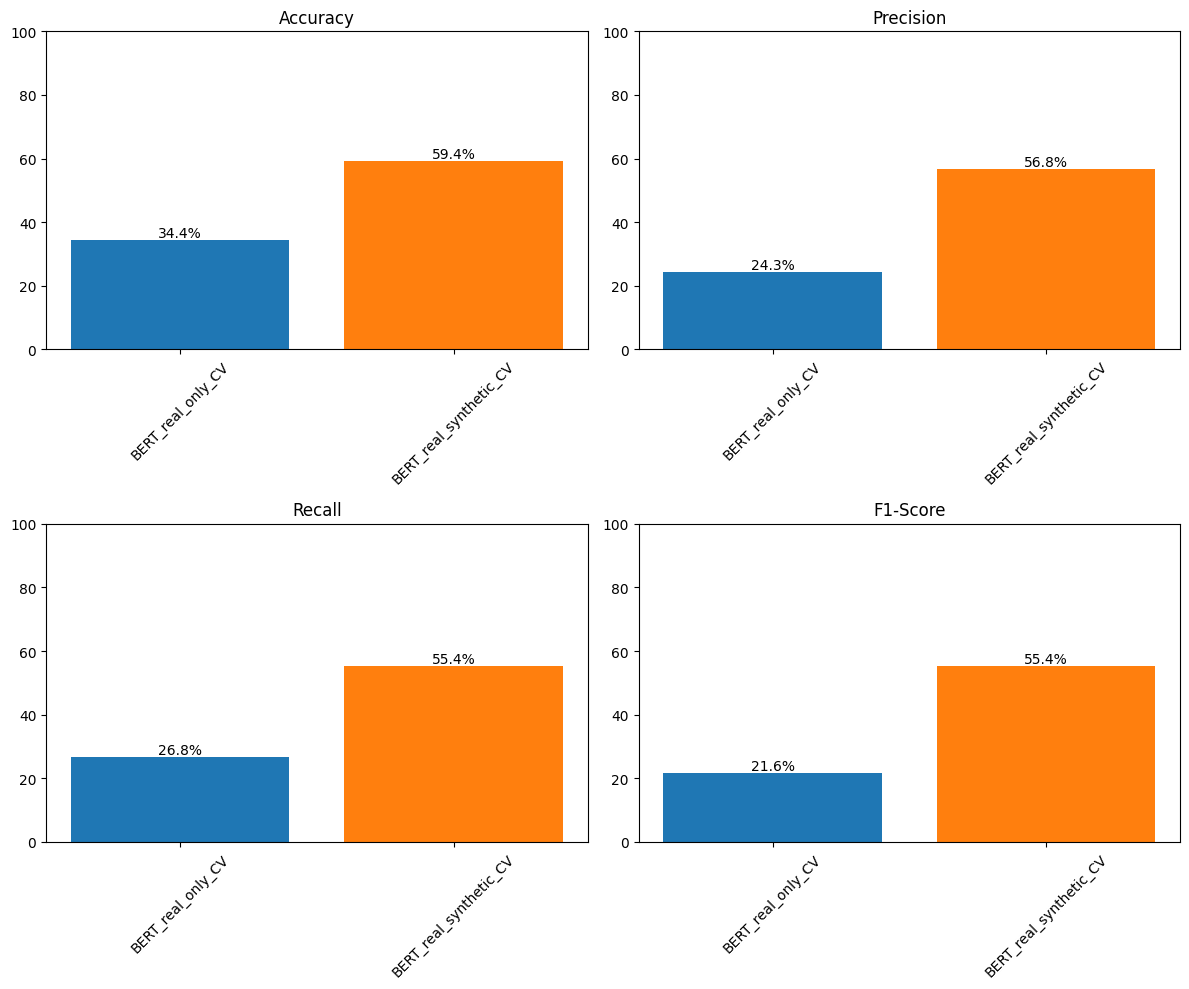

In [8]:
print(pd.DataFrame(metrics_val.results).T.round(2))
metrics_val.plot()


What we can see form the results is synthetic data substantially improves the classifier. Accuracy  rises from 34.4 to 59.4 with synthetic data added and every metric improves consistently. This makes sense, since we have a weak baseline. With only approx. 7 real examples per class, the model cannot learn all five ratings and collapses towards predicting a few of them, visible in the very low recall and precision. The syntheetic data directly addresses this by giving the model enough examples per class to represent all five ratings, explaining the large gain we see.

Moreover, the improvement is balanced across metrics, not driven by one. Precision and recall both roughly double, meaning the model is both making more correct predictions and covering more classes rather than trading one off against the other. However, one honest caveat is that the evaluation rests on the 32 pooled CV predicions which is a small test, so the exact magnitudes carry some uncertainty, so the ribust finding is the clear direction and relative size of the improvement.